# Longer stays leave less often

Tenure is an integer number of months, from 0 through 72. The 7043 tenures sum to 227990, so the mean is

$$
\dfrac{227990}{7043}.
$$

Group the months:

| Tenure | Customers | Leavers | Leave rate |
|---|---:|---:|---:|
| 0 | 11 | 0 | $0$ |
| 1 to 12 | 2175 | 1037 | $1037/2175$ |
| 13 to 24 | 1024 | 294 | $147/512$ |
| 25 to 48 | 1594 | 325 | $325/1594$ |
| 49 to 72 | 2239 | 213 | $213/2239$ |

Check the edges: $11 + 2175 + 1024 + 1594 + 2239 = 7043$, and $0 + 1037 + 294 + 325 + 213 = 1869$. The 1-to-12 rate reduces as $294/1024 = 147/512$ for the next bin, and the first-year bin $1037/2175$ is already the count.


In [1]:
# Locate the telco table beside this notebook, or under the course root.
import csv
from pathlib import Path

def data_path():
    here = Path.cwd()
    name = "Telco-Customer-Churn.csv"
    for folder in [here, *here.parents]:
        nested = folder / "16-Customer Churn" / "data" / name
        direct = folder / "data" / name
        if nested.exists():
            return nested
        if direct.exists():
            return direct
    raise FileNotFoundError(name)

def read_customers():
    with data_path().open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))
# Tenure sum, and leave rates on five bins.
from fractions import Fraction

rows = read_customers()
tenures = [int(row["tenure"]) for row in rows]
assert min(tenures) == 0 and max(tenures) == 72
assert sum(tenures) == 227990
assert Fraction(sum(tenures), 7043) == Fraction(227990, 7043)
bins = [(0, 0), (1, 12), (13, 24), (25, 48), (49, 72)]
expected = {
    (0, 0): (11, 0, Fraction(0, 1)),
    (1, 12): (2175, 1037, Fraction(1037, 2175)),
    (13, 24): (1024, 294, Fraction(147, 512)),
    (25, 48): (1594, 325, Fraction(325, 1594)),
    (49, 72): (2239, 213, Fraction(213, 2239)),
}
for low, high in bins:
    chosen = [row for row in rows if low <= int(row["tenure"]) <= high]
    left = sum(row["Churn"] == "Yes" for row in chosen)
    rate = Fraction(left, len(chosen))
    print(low, high, len(chosen), left, rate)
    assert (len(chosen), left, rate) == expected[(low, high)]


0 0 11 0 0
1 12 2175 1037 1037/2175
13 24 1024 294 147/512
25 48 1594 325 325/1594
49 72 2239 213 213/2239


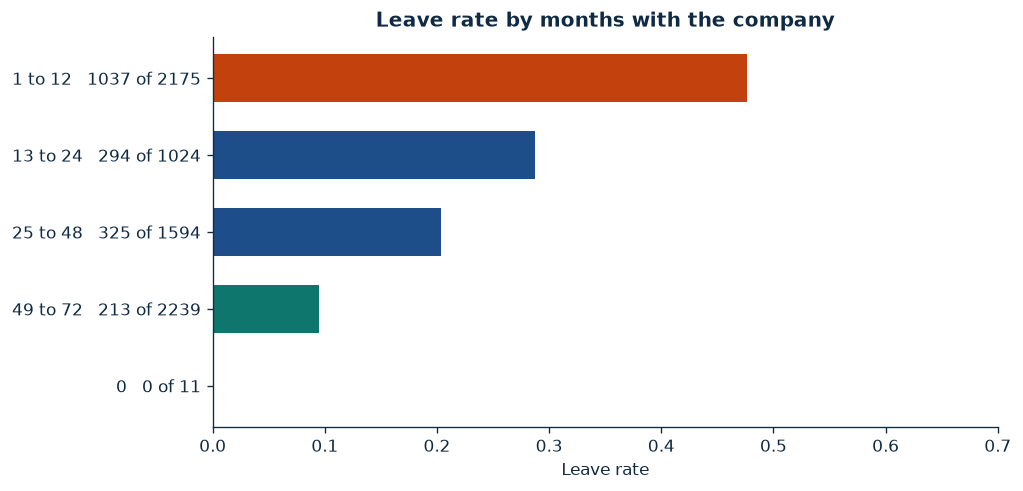

In [2]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#102a43",
    "axes.labelcolor": "#102a43",
    "xtick.color": "#102a43",
    "ytick.color": "#102a43",
    "text.color": "#102a43",
    "axes.titlecolor": "#102a43",
})
# Leave rate by tenure bin. The axis starts at zero.
from fractions import Fraction
labels = [
    "1 to 12   1037 of 2175",
    "13 to 24   294 of 1024",
    "25 to 48   325 of 1594",
    "49 to 72   213 of 2239",
    "0   0 of 11",
]
rates = [
    float(Fraction(1037, 2175)),
    float(Fraction(294, 1024)),
    float(Fraction(325, 1594)),
    float(Fraction(213, 2239)),
    0.0,
]
colors = ["#c2410c", "#1d4e89", "#1d4e89", "#0f766e", "#9fb3c8"]
positions = [4, 3, 2, 1, 0]
figure, axis = plt.subplots(figsize=(8.6, 4.2))
axis.barh(positions, rates, color=colors, height=0.62)
axis.set_yticks(positions, labels)
axis.set_xlim(0, 0.7)
axis.set_xlabel("Leave rate")
axis.set_title("Leave rate by months with the company")
figure.tight_layout()


## Pitfall

The gray bar is 11 customers at tenure 0, and the leave count on that bar is 0. A rate of 0 on 11 rows is a small bin. The clay bar, 1037 of 2175, is the first-year count.

## Summary

Tenure runs from 0 to 72 and sums to 227990. The leave rate falls from $1037/2175$ in months 1 to 12 down to $213/2239$ in months 49 to 72.
